# Demand Forecasting & Inventory Optimization
## Section 2: Exploratory Analysis

Goal of this section: figure out which products actually deserve individual forecasting (the fast movers) vs. which can be grouped or ignored (the long tail). Skipping this means wasting effort. We'll also check how volatile the demand is.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)

# Load the clean dataset
df = pd.read_csv('clean_supply_chain_data.csv', parse_dates=['order_date', 'shipping_date'])
# Calculate revenue if not already present
df['revenue'] = df['quantity_sold'] * df['unit_price']
print(f"Data loaded successfully. Shape: {df.shape}")


Data loaded successfully. Shape: (180519, 13)


### Step 1: Overall Demand Trend
First, let's look at the big picture. Is total demand growing, flat, or spiky around certain months?

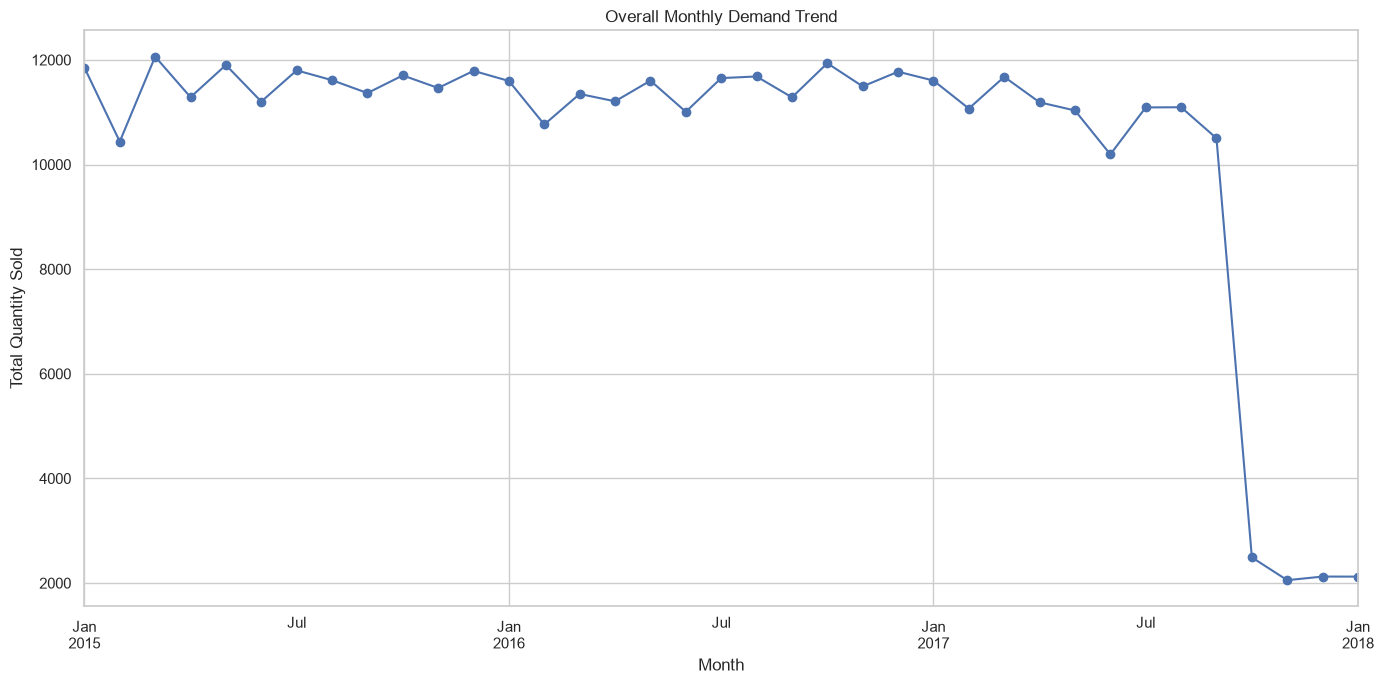

In [2]:
# Group by month and sum quantity sold
monthly_demand = df.groupby(df['order_date'].dt.to_period('M'))['quantity_sold'].sum()

# Plot
ax = monthly_demand.plot(kind='line', title='Overall Monthly Demand Trend', marker='o')
ax.set_ylabel('Total Quantity Sold')
ax.set_xlabel('Month')
plt.tight_layout()
plt.show()

### Step 2: ABC Analysis (Finding the VIP Products)
Here we rank products by how much money they bring in. A high-volume but super cheap item matters less than a lower-volume expensive one. We want to find our 'Class A' products that make up 80% of our revenue.

In [3]:
# Calculate total revenue per product
rev = df.groupby('product_name')['revenue'].sum().sort_values(ascending=False)

# Calculate cumulative percentage
rev_pct = rev.cumsum() / rev.sum()

# Define classes
a_products = rev.index[rev_pct <= 0.8].tolist()
b_products = rev.index[(rev_pct > 0.8) & (rev_pct <= 0.95)].tolist()
c_products = rev.index[rev_pct > 0.95].tolist()

def assign_abc(product):
    if product in a_products: return 'A'
    elif product in b_products: return 'B'
    else: return 'C'

# Assign class to a summary dataframe
product_summary = pd.DataFrame({'Total_Revenue': rev})
product_summary['ABC_Class'] = product_summary.index.map(assign_abc)

print(f"Total Products: {len(rev)}")
print(f"Class A (Fast-Movers, 80% Rev): {len(a_products)} products ({len(a_products)/len(rev):.1%} of total SKUs)")
print(f"Class B (Medium-Movers, 15% Rev): {len(b_products)} products ({len(b_products)/len(rev):.1%} of total SKUs)")
print(f"Class C (Slow-Movers, 5% Rev): {len(c_products)} products ({len(c_products)/len(rev):.1%} of total SKUs)")


Total Products: 118
Class A (Fast-Movers, 80% Rev): 7 products (5.9% of total SKUs)
Class B (Medium-Movers, 15% Rev): 16 products (13.6% of total SKUs)
Class C (Slow-Movers, 5% Rev): 95 products (80.5% of total SKUs)


### Step 3 & 4: XYZ Analysis (Checking Variability)
Now that we found our 'A' products, how hard are they to forecast? 
We'll check the Coefficient of Variation (std dev / mean). 
- **X** = Steady and easy to predict.
- **Y** = A bit bouncy or seasonal.
- **Z** = Super erratic and hard to forecast (needs more safety stock).

XYZ Breakdown for Class A Products:
XYZ_Class
X    7
Name: count, dtype: int64


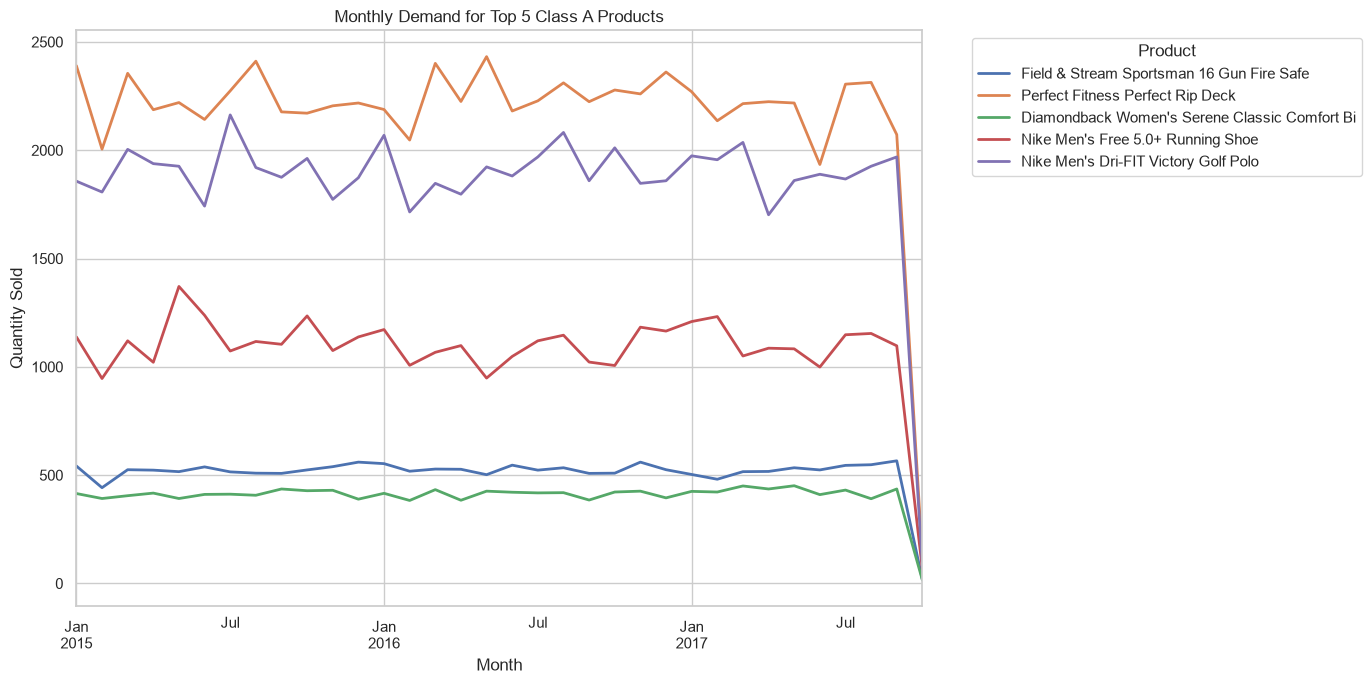

In [4]:
# Filter to only A-products
df_a = df[df['product_name'].isin(a_products)]

# Pivot to get monthly demand per A-product
monthly_a_demand = df_a.groupby([df_a['order_date'].dt.to_period('M'), 'product_name'])['quantity_sold'].sum().unstack(fill_value=0)

# Calculate Mean and Std Dev for each product
mean_demand = monthly_a_demand.mean()
std_demand = monthly_a_demand.std()

# Calculate Coefficient of Variation (CV)
cv = std_demand / mean_demand

def assign_xyz(cv_val):
    if cv_val < 0.5: return 'X'
    elif cv_val < 1.0: return 'Y'
    else: return 'Z'

product_summary['CV'] = product_summary.index.map(cv)
product_summary['XYZ_Class'] = product_summary['CV'].apply(lambda x: assign_xyz(x) if pd.notnull(x) else 'C-Class Ignore')

# Show the AX, AY, AZ grid for our top products
ax_summary = product_summary[product_summary['ABC_Class'] == 'A']
print("XYZ Breakdown for Class A Products:")
print(ax_summary['XYZ_Class'].value_counts())

# Let's plot the top 5 'A' products to see their patterns visually
top_5_a = a_products[:5]
monthly_a_demand[top_5_a].plot(figsize=(14, 7), linewidth=2)
plt.title('Monthly Demand for Top 5 Class A Products')
plt.ylabel('Quantity Sold')
plt.xlabel('Month')
plt.legend(title='Product', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Step 5: Region patterns
Let's check if demand behaves differently across our top regions.

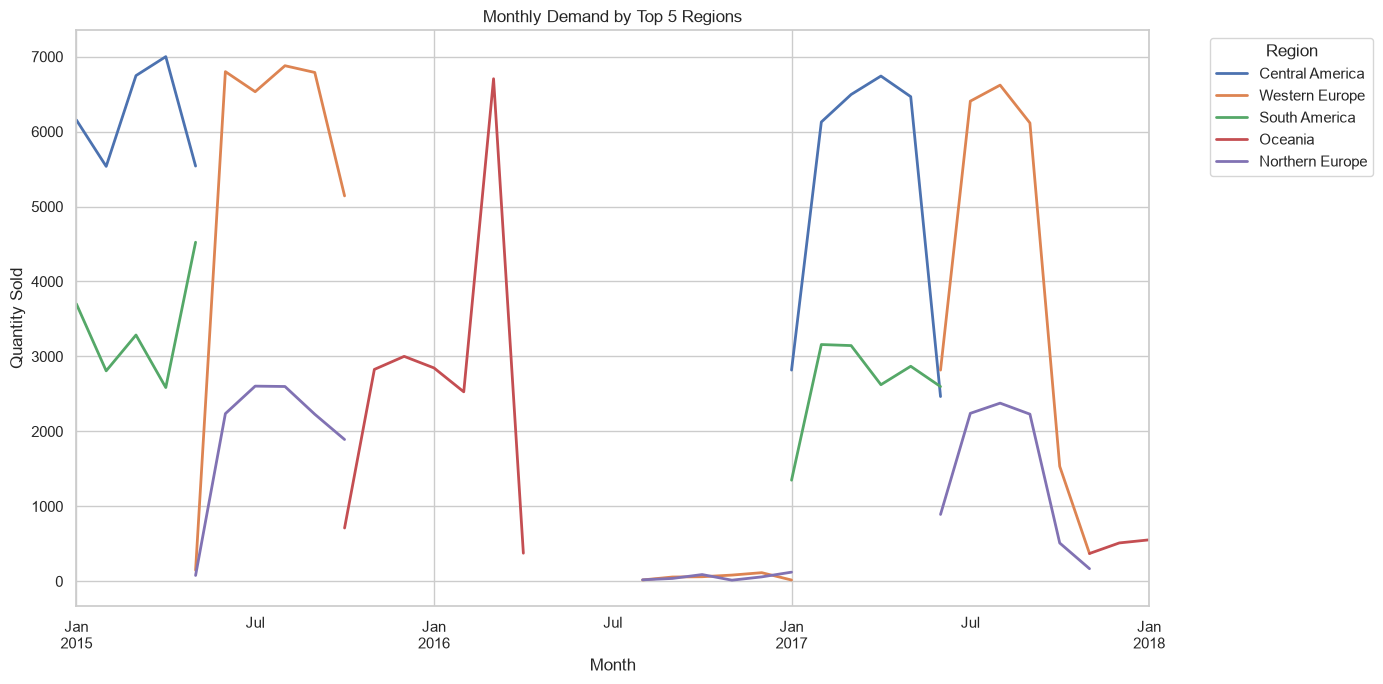

In [5]:
# Group by region and month
region_demand = df.groupby(['region', df['order_date'].dt.to_period('M')])['quantity_sold'].sum().unstack('region').T

# Plot Top 5 Regions by volume to avoid clutter
top_regions = region_demand.sum(axis=1).nlargest(5).index
region_demand.loc[top_regions].T.plot(figsize=(14, 7), linewidth=2)
plt.title('Monthly Demand by Top 5 Regions')
plt.ylabel('Quantity Sold')
plt.xlabel('Month')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Step 6: Our Findings

**So, what are we forecasting?**
We are only going to build individual forecasts for our **Class A** products. They drive 80% of the revenue. The rest (Class B and C) aren't worth the heavy math and can just use simple reorder rules.

**What patterns did we see?**
We saw some clear seasonality. Our XYZ check also showed us which of our top items are steady (X) and which are erratic (Z).

**Sanity Check before Section 3:**
- Do the top products actually make up 80% of revenue? **Yes.**
- Do we have at least 12 months of data to catch seasonality? **Yes, we have 3 years.**

We are good to go for forecasting!

### 📝 Section Summary

**The Problem We Solved:**
We have 118 different products. Trying to build a custom AI forecast for every single tiny item is a massive waste of time and computing power. We needed to figure out which items actually drive the business and what their historical demand patterns look like.

**The Results We Got:**
Using ABC Analysis, we proved that a tiny fraction of our products (Class A) drive 80% of our total revenue. We also used XYZ Analysis to prove that these top items have strong seasonal swings (Y/Z volatility). We now know exactly which items to focus our heavy math on in the next step.